# Testing of ECGDataset for ECG-Hubert. 
This should generalize to the ECG-BigBird and ECG-PatchTST models as well

In [1]:
# add autoreload
%load_ext autoreload
%autoreload 2
import neurokit2 as nk
import numpy as np
import pandas as pd
import wfdb
import os
import sys
import re
import dotenv
from collections import defaultdict
from tqdm import tqdm

import matplotlib.pyplot as plt

In [4]:
from timex.ecg import dataset

In [5]:
dotenv.load_dotenv('../.env')
BASE_DIR = os.getenv('ECG_DIR')

In [8]:
ecgConfig = dataset.Config
ecgConfig.SAMPLING_RATE = 250

ecgDS = dataset.ECGDataset(data=os.path.join(BASE_DIR, 'wilson-central-terminal-ecg-database-1.0.1'),
                           label_binarizer=None,
                           visualisation=True,
                           augmentations=[],
                           preprocessing=['savgol', 'resampler'],
                           config=ecgConfig)

First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\wilson-central-terminal-ecg-database-1.0.1\\patient001\\seg01.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\wilson-central-terminal-ecg-database-1.0.1\\patient001\\seg02.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\wilson-central-terminal-ecg-database-1.0.1\\patient001\\seg03.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\wilson-central-terminal-ecg-database-1.0.1\\patient001\\seg04.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\wilson-central-terminal-ecg-database-1.0.1\\patient002\\seg01.hea']
No labels available to show unique values


0it [00:00, ?it/s]

Visualize first 6 channels ts data: torch.Size([37, 8001])
Processing: Savitzky-Golay...
Processing: re-sampler...


\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\ecg\preprocessor.py:59: UserWarning: Number of channels 37 is not as expected: 12
  warnings.warn(f"Number of channels {self.p_signal.shape[0]} is not as expected: {num_channels}")


Visualize first 6 channels ts data: torch.Size([12, 2595])


0it [00:01, ?it/s]


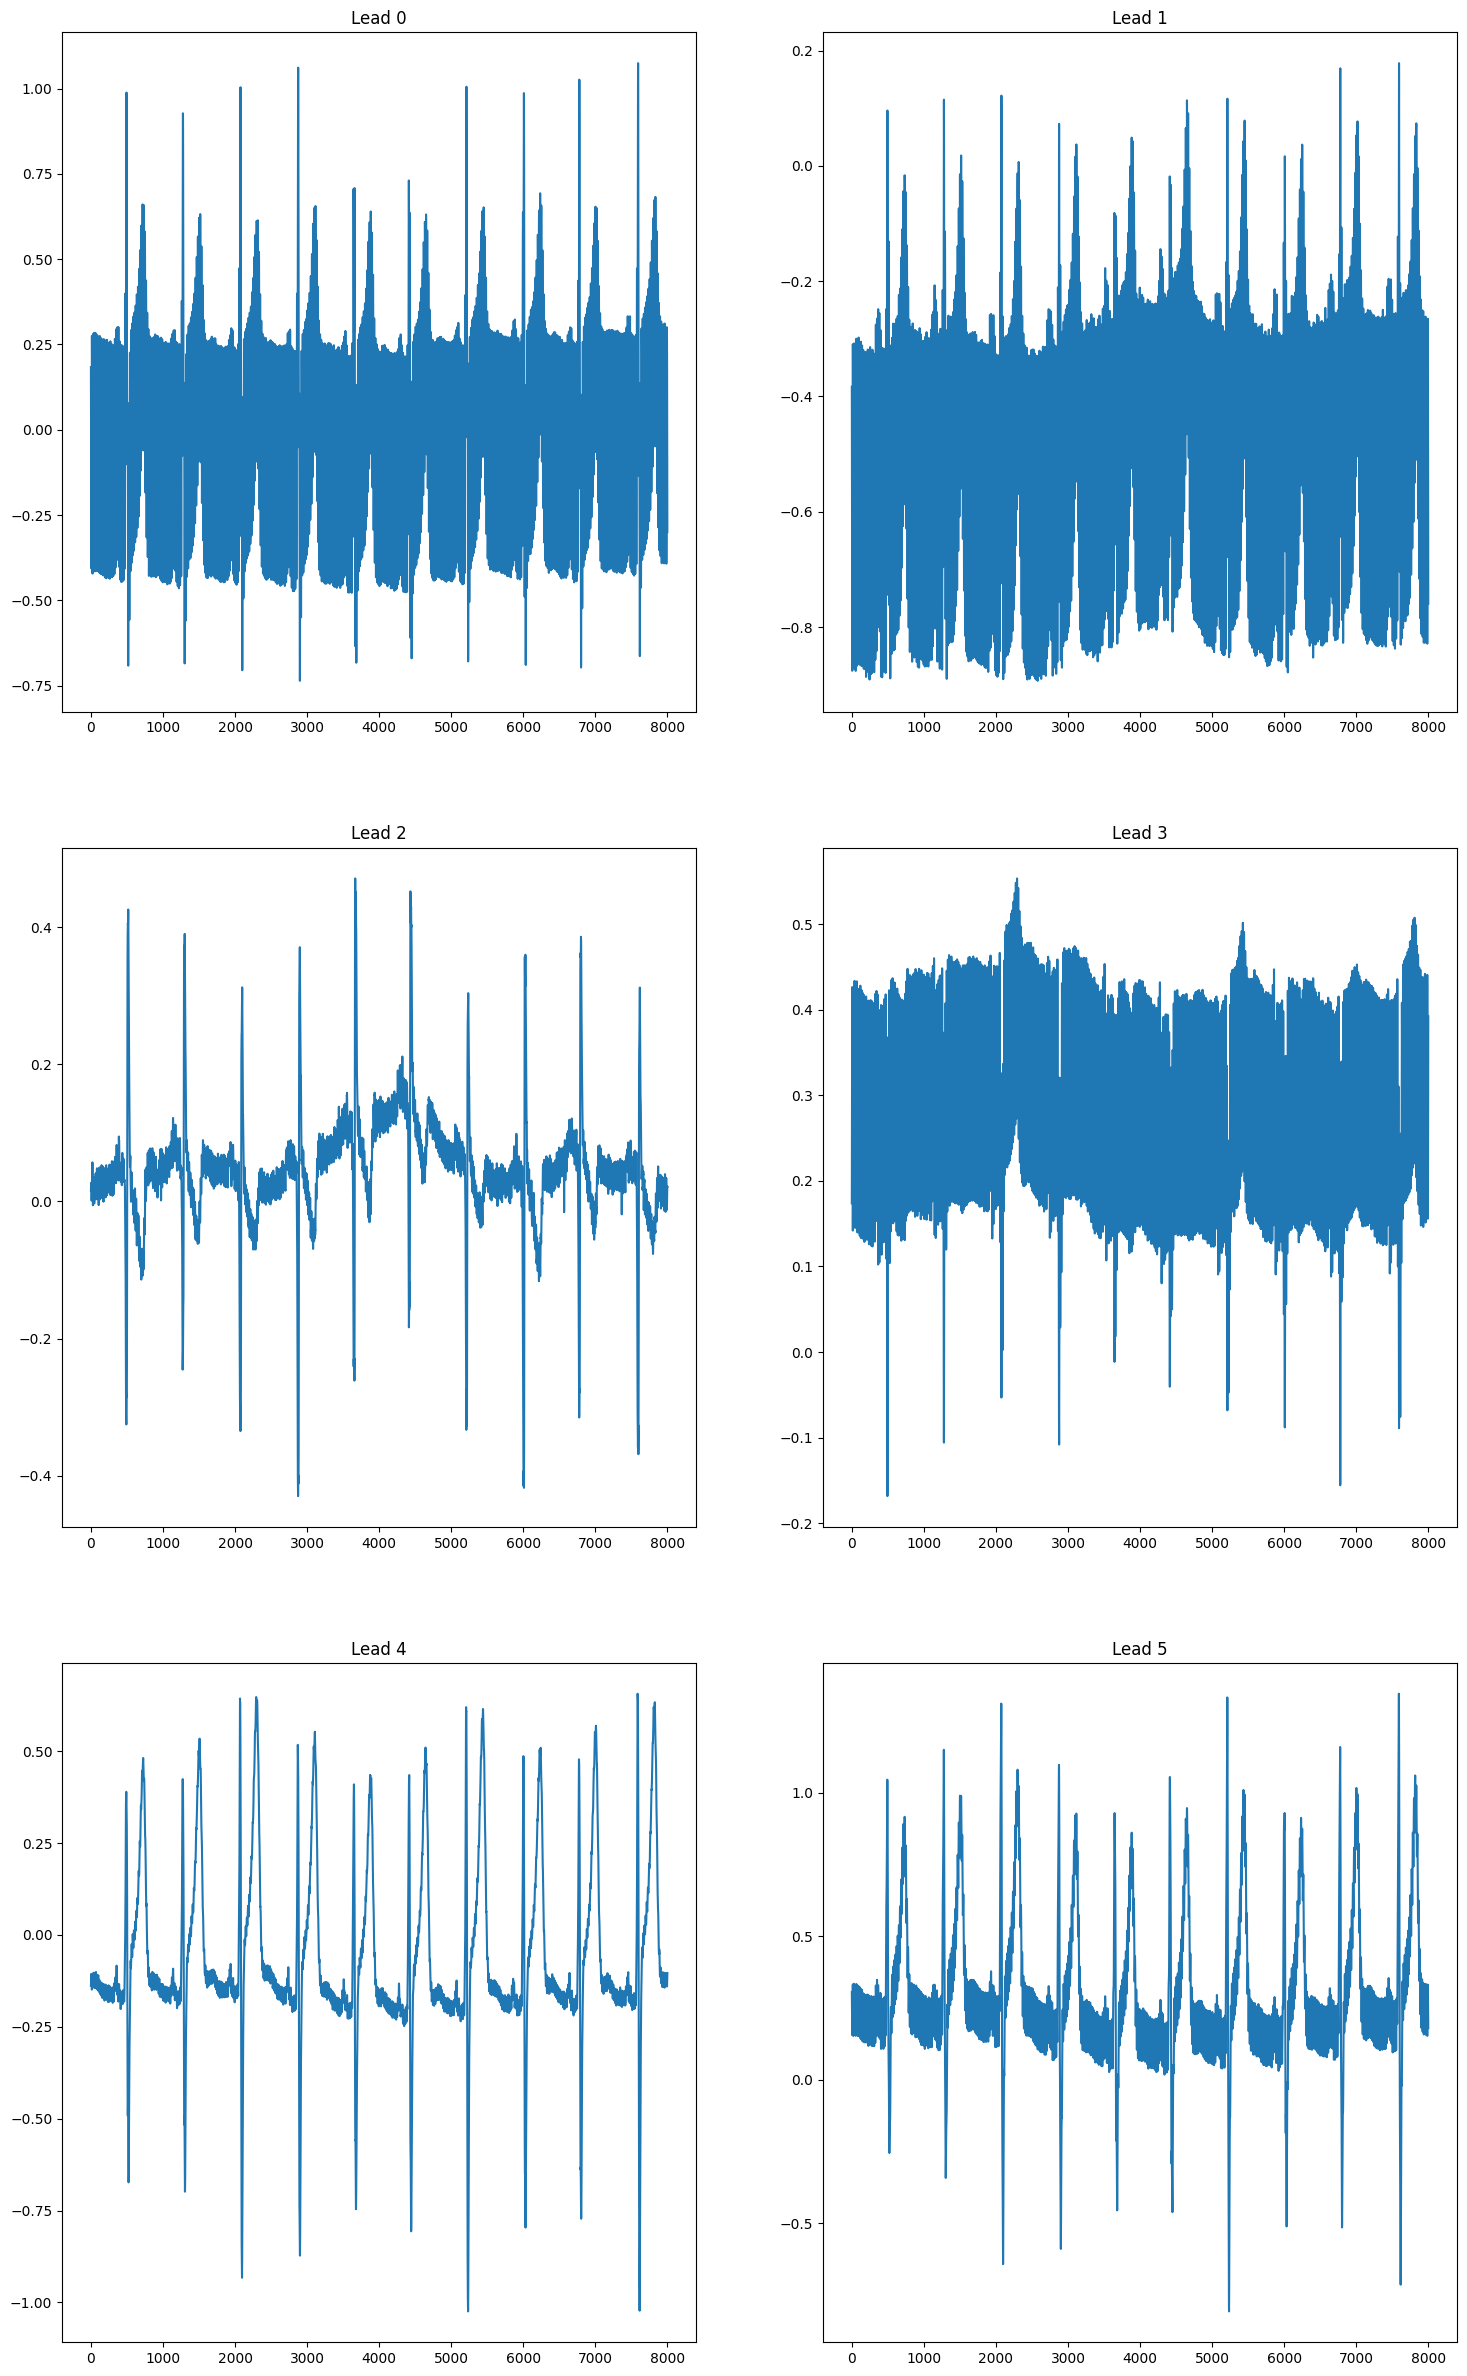

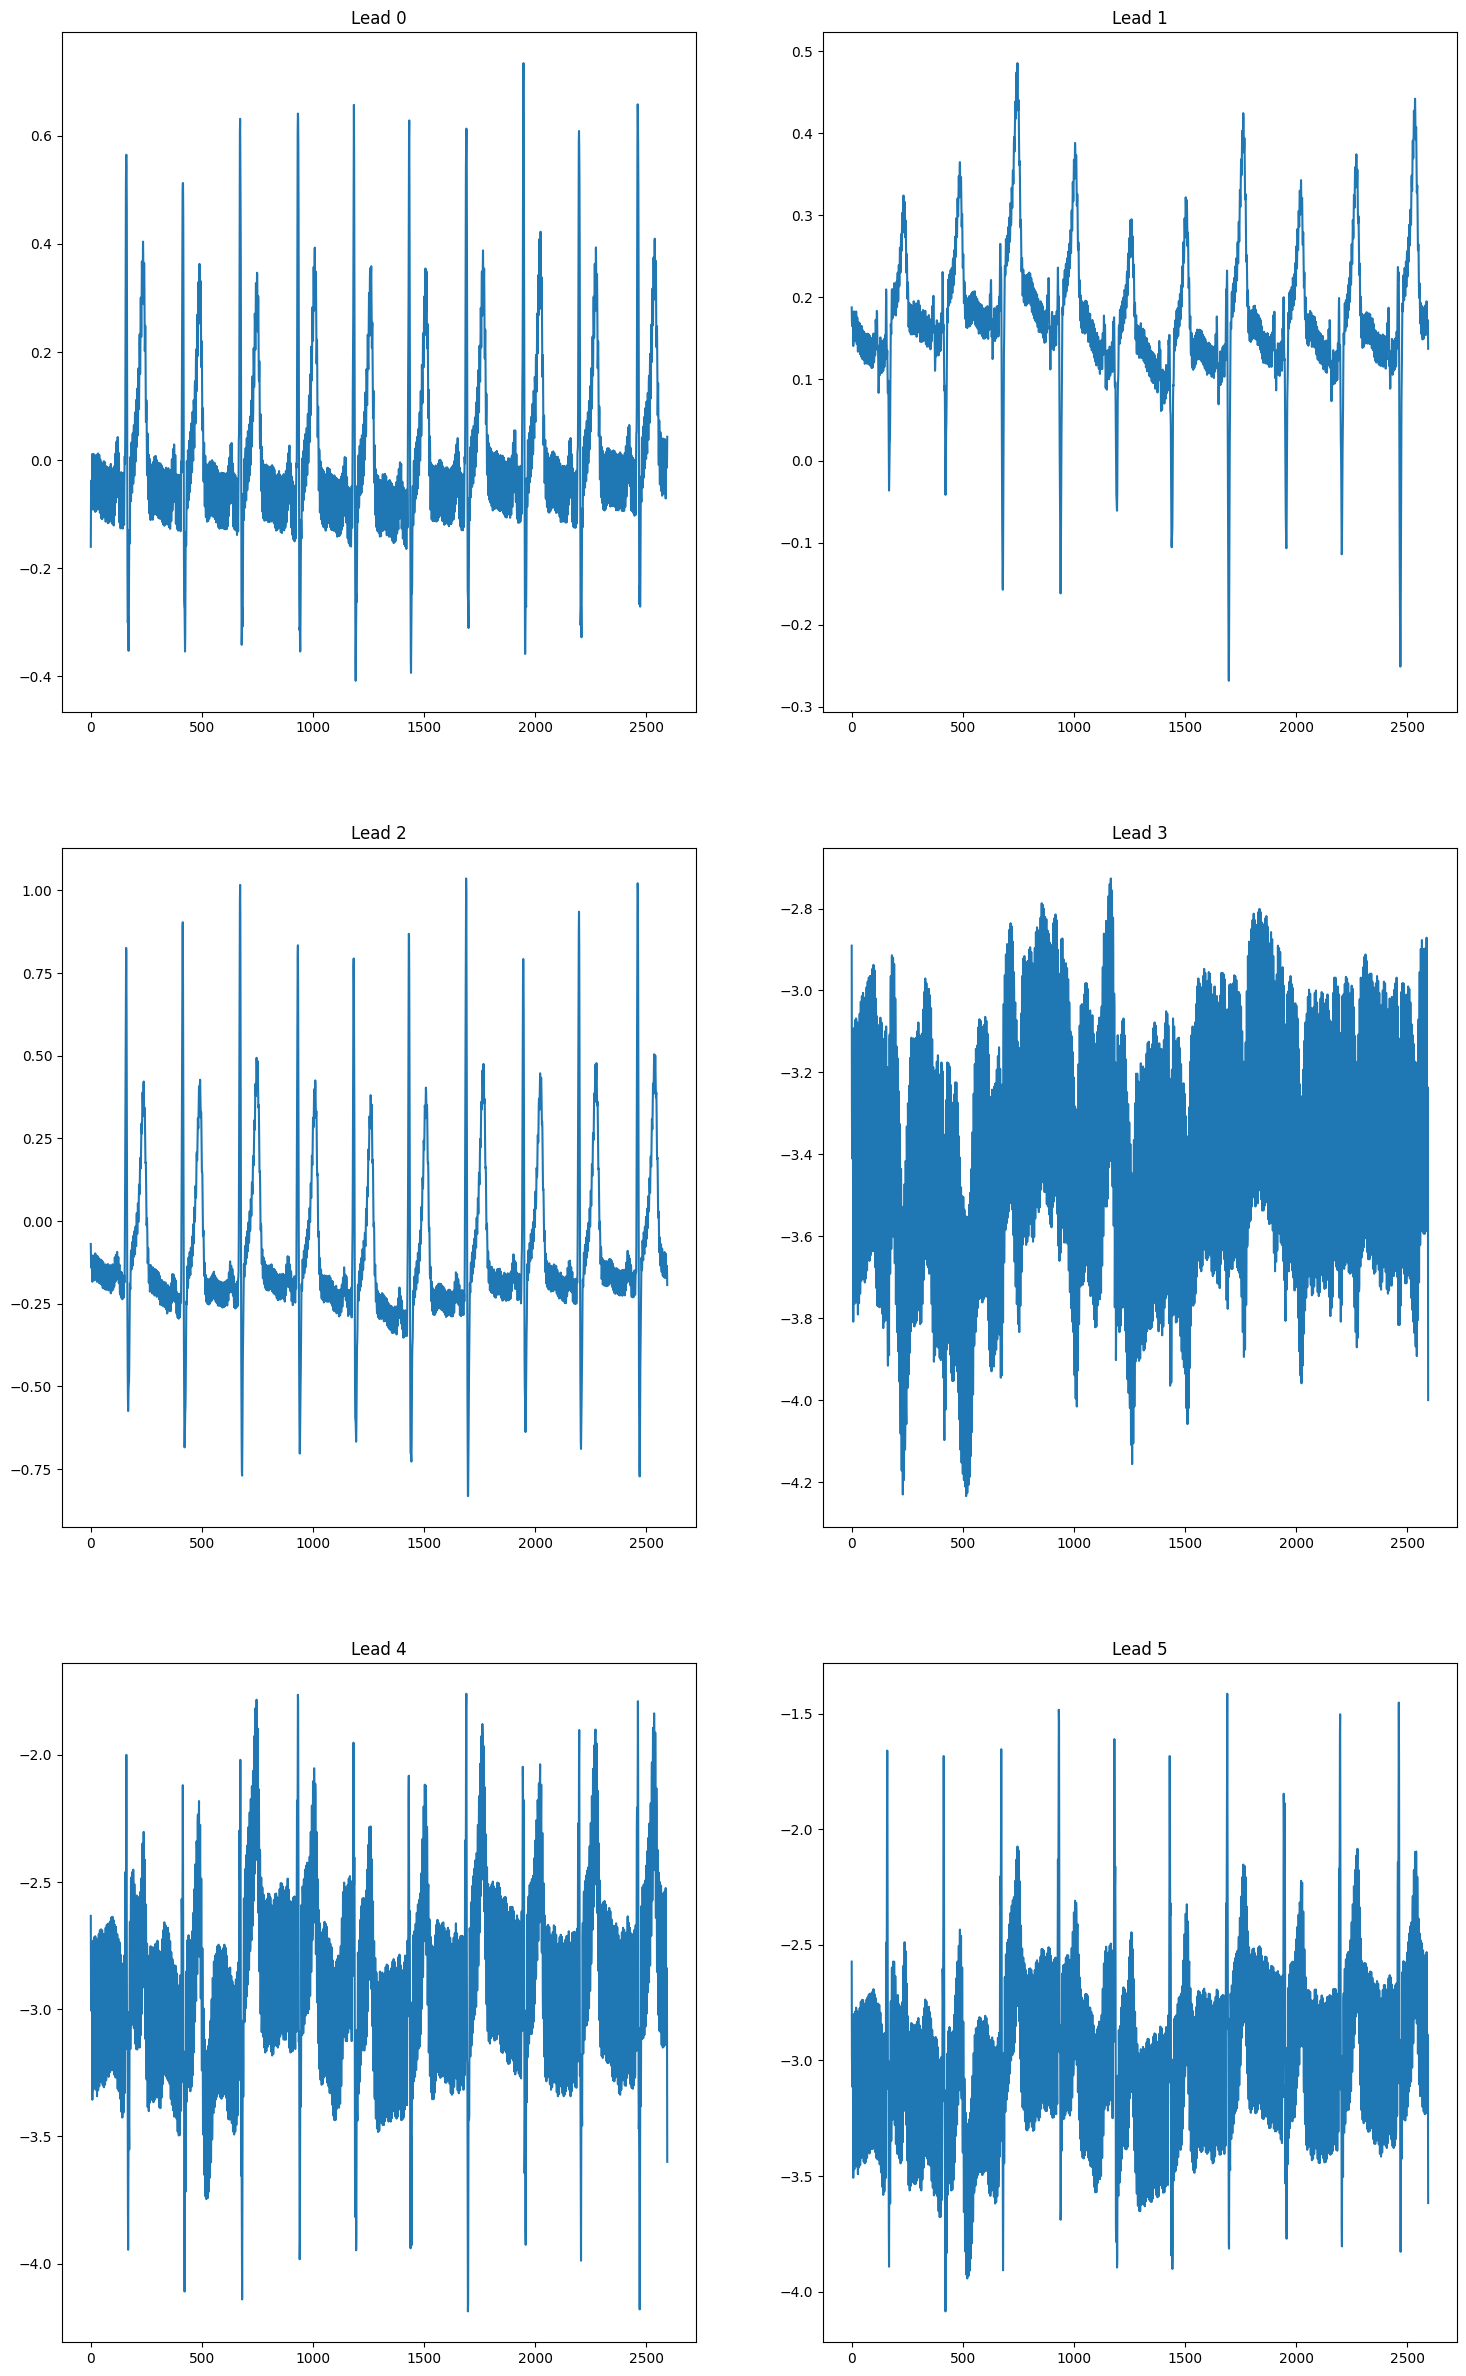

In [9]:
max_count = 0
for k, _ in tqdm(enumerate(ecgDS)):
    if k>=max_count:
        break